# Exploratory Data Analysis — Stata Auto Dataset

This notebook blends **Stata** and **Python** in a single workflow:

| Cell type | What it does |
|---|---|
| `%%stata` magic | Runs Stata commands via `pystata` (ships with Stata 17+) |
| Regular Python | Uses `pandas` and `matplotlib` for further analysis |


## 1 · Initialise pystata

`pystata` ships inside the Stata installation folder.  
Adjust the path below only if Stata is installed somewhere other than `C:\Program Files\Stata18`.

In [6]:
import sys
sys.path.append(r"C:\Program Files\Stata18\utilities")

import pystata
# Edition: "se" = StataSE  |  "mp" = Stata/MP  |  "be" = Stata/BE
pystata.config.init("se")

## 2.Run Do File

In [7]:
%%stata
do "clean_data.do"


. * ===========================================================================
> ==
. * clean_data.do
. * Loads Stata's built-in auto dataset, performs basic cleaning, and saves
. * a cleaned copy to data/auto_clean.dta for use in the EDA notebook.
. * ===========================================================================
> ==
. 
. * ── 0. Working directory ───────────────────────────────────────────────────
> ──
. * Stata sets the working directory to the folder containing this do-file
. * when you run it with the VSCode extension (Run button / Ctrl+Shift+D).
. * If that is not the case, uncomment and adjust the line below:
. * cd "C:\Users\localuser\my_projects\demo_app"
. 
. * ── 1. Load raw data ───────────────────────────────────────────────────────
> ───
. sysuse auto, clear          // ships with every Stata installation
(1978 automobile data)

. 
. * ── 2. Inspect ─────────────────────────────────────────────────────────────
> ──
. describe

Contains data from C:\Program

## 2 · Quick Stata summary (Stata cell)

In [8]:
%%stata
use "data/auto_clean.dta", clear
describe
summarize price mpg weight repair_record price_per_mpg
tabulate foreign


. use "data/auto_clean.dta", clear
(1978 automobile data)

. describe

Contains data from data/auto_clean.dta
 Observations:            69                  1978 automobile data
    Variables:            13                  15 Jul 2026 11:28
                                              (_dta has notes)
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
make            str18   %-18s                 Make and model
price           int     %8.0gc                Price
mpg             int     %8.0g                 Mileage (mpg)
repair_record   int     %8.0g                 Repair record 1978
headroom        float   %6.1f                 Headroom (in.)
trunk           int     %8.0g                 Trunk space (cu. ft.)
weight          int     %8.0gc                Weight (lbs.)
length

## 3 · Load cleaned data into pandas

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_stata("data/auto_clean.dta")

print(f"Rows: {len(df)}  |  Columns: {df.shape[1]}")
df.head()

Rows: 69  |  Columns: 13


,make,price,mpg,repair_record,headroom,trunk,weight,length,turn,displacement,gear_ratio,foreign,price_per_mpg
0,AMC Concord,4099,22,3,2.5,11,2930,186,40,121,3.58,Domestic,186.318176
1,AMC Pacer,4749,17,3,3.0,11,3350,173,40,258,2.53,Domestic,279.352936
2,Buick Century,4816,20,3,4.5,16,3250,196,40,196,2.93,Domestic,240.800003
3,Buick Electra,7827,15,4,4.0,20,4080,222,43,350,2.41,Domestic,521.799988
4,Buick LeSabre,5788,18,3,4.0,21,3670,218,43,231,2.73,Domestic,321.555542


In [10]:
df.describe()

,price,mpg,repair_record,headroom,trunk,weight,length,turn,displacement,gear_ratio,price_per_mpg
count,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000,69.00000,69.000000,69.000000
mean,6146.043478,21.289855,3.405797,3.000000,13.927536,3032.028986,188.289855,39.797101,198.00000,2.999275,329.500671
std,2912.440252,5.866408,0.989932,0.853195,4.343077,792.851480,22.747399,4.441051,93.14789,0.462682,232.792831
min,3291.000000,12.000000,1.000000,1.500000,5.000000,1760.000000,142.000000,31.000000,79.00000,2.190000,108.514282
25%,4195.000000,18.000000,3.000000,2.500000,11.000000,2240.000000,170.000000,36.000000,119.00000,2.730000,179.279999
50%,5079.000000,20.000000,3.000000,3.000000,15.000000,3200.000000,193.000000,40.000000,196.00000,2.930000,250.888885
75%,6303.000000,24.000000,4.000000,3.500000,17.000000,3670.000000,204.000000,43.000000,250.00000,3.300000,373.058838
max,15906.000000,41.000000,5.000000,5.000000,23.000000,4840.000000,233.000000,51.000000,425.00000,3.890000,1132.833374


## 4 · Price distribution

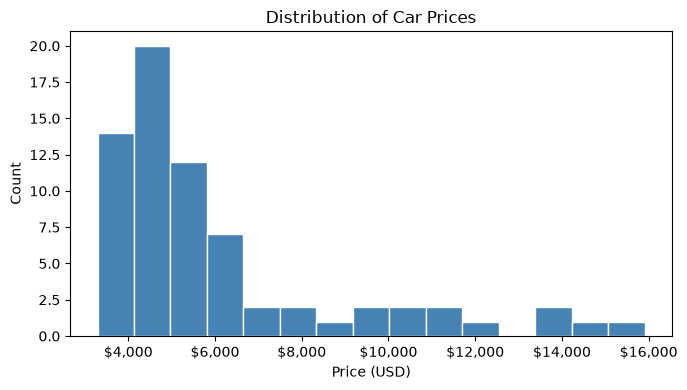

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["price"], bins=15, edgecolor="white", color="steelblue")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Car Prices")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 5 · Price vs. MPG by origin

C:\Users\localuser\AppData\Local\Temp\ipykernel_15236\3871969138.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for origin, group in df.groupby("foreign"):


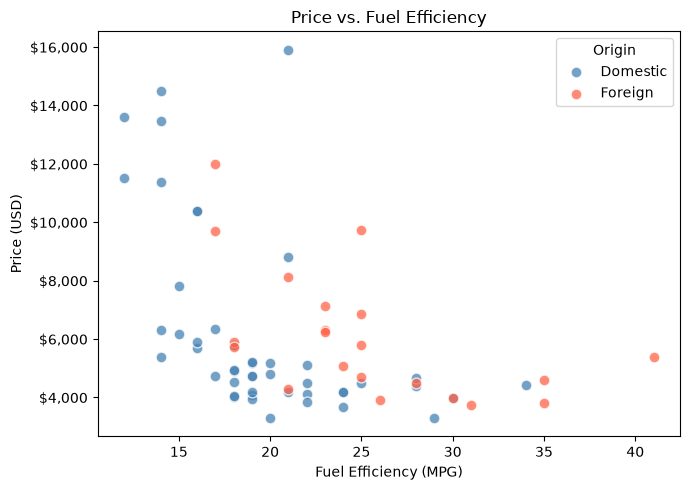

In [12]:
colors = {"Domestic": "steelblue", "Foreign": "tomato"}

fig, ax = plt.subplots(figsize=(7, 5))
for origin, group in df.groupby("foreign"):
    ax.scatter(group["mpg"], group["price"], label=origin,
               color=colors[origin], alpha=0.75, edgecolors="white", s=60)

ax.set_xlabel("Fuel Efficiency (MPG)")
ax.set_ylabel("Price (USD)")
ax.set_title("Price vs. Fuel Efficiency")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Origin")
plt.tight_layout()
plt.show()

## 6 · Price by origin — box plot

C:\Users\localuser\AppData\Local\Temp\ipykernel_15236\2002219281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [grp["price"].values for _, grp in df.groupby("foreign")]


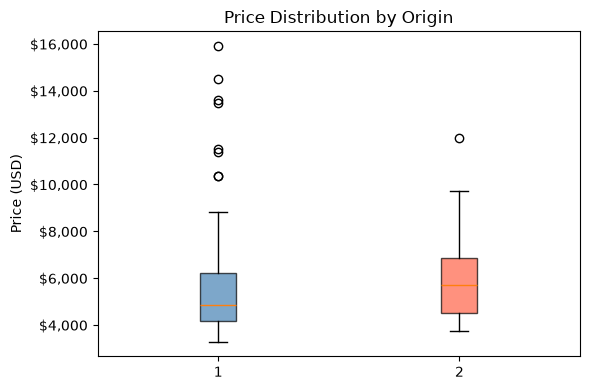

In [14]:
groups = [grp["price"].values for _, grp in df.groupby("foreign")]
labels = [str(k) for k in df["foreign"].cat.categories]

fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(groups, patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue", "tomato"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Price (USD)")
ax.set_title("Price Distribution by Origin")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 7 · Quick Stata regression (Stata cell)

Round-trip: pass the pandas DataFrame back into Stata, run a regression, display results.

In [15]:
# Push the DataFrame into Stata's active dataset
from pystata import stata

# Assuming your DataFrame is called df
stata.pdataframe_to_data(df, force=True)

In [16]:
#If you'd rather save to a .dta file first and then load it in Stata, you can do that too:
df.to_stata('mydata.dta', write_index=False)

In [17]:
%%stata
use "mydata.dta", clear
regress price mpg weight i.repair_record i.foreign
estat summarize


. use "mydata.dta", clear

. regress price mpg weight i.repair_record i.foreign

      Source |       SS           df       MS      Number of obs   =        69
-------------+----------------------------------   F(7, 61)        =      8.78
       Model |   289409242         7  41344177.4   Prob > F        =    0.0000
    Residual |   287387717        61  4711274.05   R-squared       =    0.5018
-------------+----------------------------------   Adj R-squared   =    0.4446
       Total |   576796959        68  8482308.22   Root MSE        =    2170.5

------------------------------------------------------------------------------
       price | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         mpg |   24.37505   81.24383     0.30   0.765     -138.082    186.8321
      weight |   3.545366   .6740969     5.26   0.000     2.197426    4.893306
             |
repair_rec~d |
          2  |   5